### Create classification model

In [2]:
%pip install pandas numpy scikit-learn

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
import skl2onnx
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import StringTensorType
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


# Sample data
df = pd.read_csv('dish_classifier_data.csv')
df = df.dropna(subset=['text', 'label'])
print(df.head())
print(df.info())
print(df.describe())
print(df['label'].value_counts())

# Split the data
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

                   text     label
0  Taxes Extra material  not_dish
1            Cold sport  not_dish
2                     *  not_dish
3         Hot executive  not_dish
4              Hot sell  not_dish
<class 'pandas.core.frame.DataFrame'>
Index: 12782 entries, 0 to 12782
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    12782 non-null  object
 1   label   12782 non-null  object
dtypes: object(2)
memory usage: 299.6+ KB
None
                    text     label
count              12782     12782
unique              5955         3
top     Margherita Pizza  not_dish
freq                 539      6924
label
not_dish    6924
dish        5853
label          5
Name: count, dtype: int64


Accuracy: 0.986703167774736
              precision    recall  f1-score   support

        dish       1.00      0.97      0.99      1163
       label       0.00      0.00      0.00         2
    not_dish       0.98      1.00      0.99      1392

    accuracy                           0.99      2557
   macro avg       0.66      0.66      0.66      2557
weighted avg       0.99      0.99      0.99      2557



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


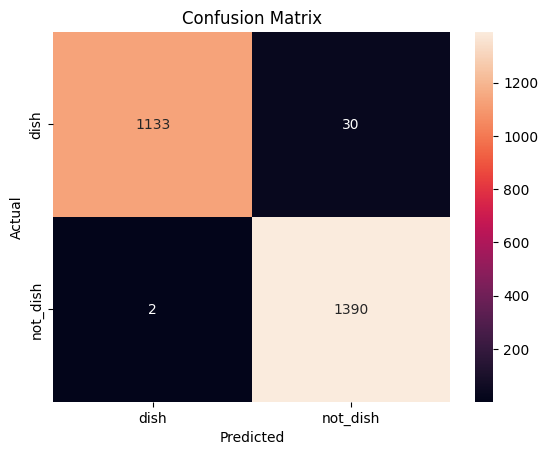

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(ngram_range=(1,2))),
    ('classifier', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['dish', 'not_dish'])
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['dish', 'not_dish'], yticklabels=['dish', 'not_dish'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


## Export

In [9]:
import numpy as np

probs = pipeline.predict_proba(X_test)
threshold = 0.7
y_pred_thresh = []

for p in probs:
    if max(p) >= threshold:
        y_pred_thresh.append(pipeline.classes_[np.argmax(p)])
    else:
        y_pred_thresh.append("not_dish")  # or "uncertain"

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import StringTensorType

import pickle

with open('dish_classifier.pkl', 'wb') as f:
    pickle.dump(pipeline, f)


### prompt testing

In [10]:
import pickle
import pandas as pd

# Load the .pkl model
with open('dish_classifier.pkl', 'rb') as f:
  model = pickle.load(f)
  # Run predictions
  for text in df['text']:
      prediction = model.predict([text])[0]
      print(f"input: {text} → Prediction: {prediction}")


Streaming output truncated to the last 5000 lines.
input: Chicken Biryani → Prediction: dish
input: Price Varies glass → Prediction: not_dish
input: Chef's Special hospital → Prediction: not_dish
input: Chef's Special list → Prediction: not_dish
input: No Onion least → Prediction: not_dish
input: Chef's Special rate → Prediction: not_dish
input: Chef's Special about → Prediction: not_dish
input: Hot true → Prediction: not_dish
input: Tandoori Roti → Prediction: dish
input: Butter Chicken → Prediction: dish
input: Margherita Pizza → Prediction: dish
input: Margherita Pizza → Prediction: dish
input: Paneer Tikka → Prediction: dish
input: Sushi Roll → Prediction: dish
input: Set Menu → Prediction: not_dish
input: Sushi Roll → Prediction: dish
input: Chef's Special box → Prediction: not_dish
input: No Onion certain → Prediction: not_dish
input: Taxes Extra across → Prediction: not_dish
input: Margherita Pizza → Prediction: dish
input: Serving Size democratic → Prediction: not_dish
input: H